In [21]:
# In this notebook, we are going to implement the refinement block of the CRAG architecture in the research paper.
# We will assume that the docs provided by the retriever fall in the "Correct" category. 

In [22]:
from typing import List, TypedDict
from pydantic import BaseModel
import time
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [23]:
load_dotenv()

True

In [24]:
docs = (
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book1.pdf").load() + 
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book2.pdf").load() + 
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day25_Corrective_RAG\books\book3.pdf").load()
)

In [25]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 900, chunk_overlap = 150)

chunks = splitter.split_documents(docs)

In [26]:
# Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [27]:
embedding_model = OpenAIEmbeddings(model = "text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embedding = embedding_model)

In [28]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [ ]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

In [30]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

In [31]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [32]:
# Sentence-level DECOMPOSER
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# FILTER (LLM judge)
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only."
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}")
    ]
)

# Waise in the research paper, the researchers fine tuned the google t5-large LLM for the filtration task.
# The advantage of this fine-tuned LLM is that it has only about 770 million parameters. So, it is much lighter than GPT models and also, it's performance in this filtration task is better than all the other models.
# But we don't have access to this fine tuned LLM as the researchers haven't made this fine tuned LLM public yet, therefore we are going to use GPT chat model here.

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State):
    q = state['question']
    context = "\n\n".join(d.page_content for d in state['docs'])
    strips = decompose_to_sentences(context)

    kept_strips: List[str] = []
    for strip in strips:
        if filter_chain.invoke({"question": q, "sentence": strip}).keep:
            kept_strips.append(strip)
    
    refined_context = "\n".join(kept_strips).strip()

    return {
        "strips": strips,
        "kept_strips": kept_strips,
        "refined_context": refined_context
    }

In [33]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'"
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}")
    ]
)

def generate(state: State):
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state["refined_context"]}).content
    return {"answer": out}

In [34]:
graph = StateGraph(State)

graph.add_node("retrieve", retrieve)
graph.add_node("refine", refine)
graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)

workflow = graph.compile()

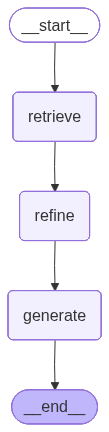

In [35]:
workflow

In [36]:
res = workflow.invoke({
    "question": "Explain the bias-variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

The bias-variance tradeoff is a fundamental concept in statistics and machine learning that describes the relationship between two sources of error in an estimator: bias and variance.

- **Bias** measures the expected deviation from the true value of the function or parameter. A high-bias model is likely to underfit the training data, often due to incorrect assumptions about the data (e.g., assuming linearity when the relationship is quadratic).

- **Variance** measures the model's sensitivity to small variations in the training data. A model with high variance may fit the training data very well but perform poorly on unseen data due to overfitting.

- The generalization error of a model can be expressed as the sum of bias, variance, and a constant noise term. 

- There is a trade-off between bias and variance: flexible models tend to have low bias and high variance, while rigid models have high bias and low variance.

- The goal is to minimize expected loss by finding the optimal bala

In [37]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared
Error
Bias and variance measure two diﬀerent sources of error in an estimator. Bias
measures the expected deviation from the true value of the function or parameter.
Variance on the other hand, provides a measure of the deviation from the expected
estimator value that any particular sampling of the data is likely to cause.
What happens when we are given a choice between two estimators, one with
more bias and one with more variance? How do we choose between them? For
example, imagine that we are interested in approximating the function shown in
ﬁgure and we are only oﬀered the choice between a model with large bias and5.2
one that suﬀers from large variance. How do we choose between them?
The most common way to negotiate this trade-oﬀ is to use cross-validation.
****************************************************************************************************
10 This notion of bias is not to be confused with the bias term of linear 

In [38]:
print(res['refined_context'])

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared Error Bias and variance measure two diﬀerent sources of error in an estimator.
Bias measures the expected deviation from the true value of the function or parameter.
What happens when we are given a choice between two estimators, one with more bias and one with more variance?
For example, imagine that we are interested in approximating the function shown in ﬁgure and we are only oﬀered the choice between a model with large bias and5.2 one that suﬀers from large variance.
The Bias/Variance Tradeoff An importan t theoretical result of statistics and Machine Learning is the fact that a model’s generaliza tion error can be expressed as the sum of three very different errors: Bias This part of the generalization error is due to wrong assumptions, such as assum‐ ing that the data is linear when it is actually quadratic.
A high-bias model is most likely to underfit the training data.10 Variance This part is due to the model’s excessive sens